<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/14_CNN_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Cross-Correlation Operation

Now that we understand why CNNs are useful, the next question is:

> **How does a CNN actually extract features from an image?**

The answer is through an operation called **cross-correlation**.

A cross-correlation operation slides a small matrix, called a **kernel** (or **filter**), across an image.

At each position:

1. The kernel overlaps a small region of the image.
2. Corresponding values are multiplied together.
3. The products are summed.
4. The result becomes one value in the output feature map.

This process is repeated as the kernel moves across the entire image.

> **Note:** Although deep learning libraries perform *cross-correlation*, it is commonly referred to as **convolution** in CNN literature.

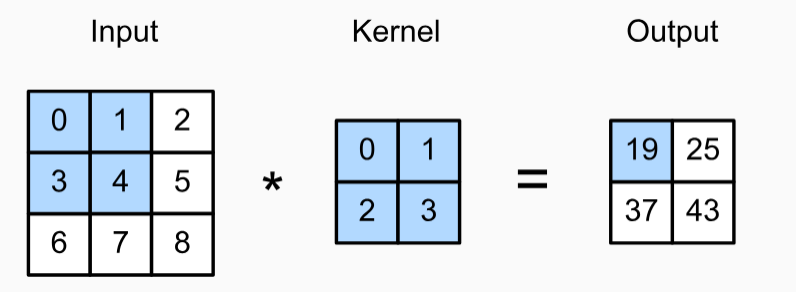

### Computing One Output Value

The figure above illustrates how the first value of the output feature map is computed.

The kernel is first placed over the upper-left corner of the input image.

```
Input Patch          Kernel

0   1               0   1
3   4               2   3
```

Each pair of corresponding elements is multiplied together.

The products are then added:

**(0 × 0) + (1 × 1) + (3 × 2) + (4 × 3) = 19**

Therefore, the first output value is:

**19**

Next, the kernel slides one position to the right and repeats the same computation.

This process continues until every valid position has been visited, producing the complete output feature map.

### Output Size

Notice that the output feature map is **smaller** than the input image.

This happens because the kernel must fit completely inside the image when performing the computation.

If:

- the input image has height **H** and width **W**
- the kernel has height **K<sub>h</sub>** and width **K<sub>w</sub>**

then the output size is:

$$
(H-K_h+1)\times(W-K_w+1)
$$

For example:

- Input image: **3 × 3**
- Kernel: **2 × 2**

Output:

$$
(3-2+1)\times(3-2+1)=2\times2
$$

which matches the output shown in the figure.

## Implementing Cross-Correlation

The following function implements the cross-correlation operation.

For every possible kernel position:

1. A small image patch is extracted.
2. The patch is multiplied element by element with the kernel.
3. The products are summed.
4. The result is stored in the corresponding position of the output feature map.

Although TensorFlow already provides optimized convolution operations, implementing the algorithm ourselves helps us understand exactly how convolution works.

In [1]:
!pip install -q D2L --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 4.3 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from d2l import tensorflow as d2l

In [3]:
def corr2d(X, K):
    """Compute the two-dimensional cross-correlation of input X and kernel K. Parameters----------
    X : tf.Tensor
        Two-dimensional input tensor, such as an image.

    K : tf.Tensor
        Two-dimensional kernel (filter).

    Returns
    -------
    tf.Variable
        The output feature map produced by sliding K across X.
    """

    # Get the kernel's height and width
    kernel_height, kernel_width = K.shape

    # Calculate the output dimensions:
    # output height = input height - kernel height + 1
    # output width  = input width  - kernel width  + 1
    output_height = X.shape[0] - kernel_height + 1
    output_width = X.shape[1] - kernel_width + 1

    # Create an output tensor initialized with zeros
    Y = tf.Variable(
        tf.zeros((output_height, output_width), dtype=X.dtype)
    )

    # Move the kernel vertically across every valid input position
    for i in range(output_height):

        # Move the kernel horizontally across every valid input position
        for j in range(output_width):

            # Extract the input patch currently covered by the kernel
            input_patch = X[
                i:i + kernel_height,
                j:j + kernel_width
            ]

            # Multiply corresponding values and add all products
            output_value = tf.reduce_sum(input_patch * K)

            # Store the result in the corresponding output position
            Y[i, j].assign(output_value)

    # Return the completed output feature map
    return Y

### Testing the Implementation

We now verify that our implementation produces the same output as the example shown earlier.

The following code creates the input image and kernel from the figure and applies the `corr2d()` function.

The output should be:

```
[[19, 25],
 [37, 43]]
```

which matches the manually computed result.

In [4]:
# Create the 3 x 3 input tensor shown in the example
X = tf.constant([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
])

# Create the 2 x 2 kernel shown in the example
K = tf.constant([
    [0.0, 1.0],
    [2.0, 3.0]
])

# Apply the cross-correlation operation
Y = corr2d(X, K)

# Display the input, kernel, and resulting feature map
print("Input tensor:")
print(X.numpy())

print("\nKernel:")
print(K.numpy())

print("\nOutput feature map:")
print(Y.numpy())

Input tensor:
[[0. 1. 2.]
 [3. 4. 5.]
 [6. 7. 8.]]

Kernel:
[[0. 1.]
 [2. 3.]]

Output feature map:
[[19. 25.]
 [37. 43.]]


Top-left:     (0×0) + (1×1) + (3×2) + (4×3) = 19

Top-right:    (1×0) + (2×1) + (4×2) + (5×3) = 25

Bottom-left:  (3×0) + (4×1) + (6×2) + (7×3) = 37

Bottom-right: (4×0) + (5×1) + (7×2) + (8×3) = 43

## Convolutional Layers

In the previous section, we manually implemented the **cross-correlation operation** using the `corr2d()` function.

In practice, a convolutional layer simply wraps this operation into a trainable neural network layer.

A convolutional layer contains two learnable parameters:

- **Kernel (Filter):** learns the pattern to detect.
- **Bias:** a single value added to every output element.

During training, both the kernel values and the bias are updated automatically through backpropagation.

The output of a convolutional layer is therefore

```
Output = Cross-Correlation(Input, Kernel) + Bias
```

Unlike the previous example where we manually specified the kernel values, the network starts with randomly initialized kernels and gradually learns useful filters from the training data.

### Example: Building a Simple Convolutional Layer

In [5]:
import tensorflow as tf

# Create a convolutional layer
conv = tf.keras.layers.Conv2D(
    filters=1,          # Learn one filter
    kernel_size=(2, 2), # 2×2 kernel
    strides=1,#Move the kernel one pixel at a time.
    padding="valid", #The output becomes smaller than the input.
    use_bias=True #Add one learnable bias after the cross-correlation.
)

### Key Points

- A convolutional layer performs the cross-correlation operation.
- The kernel values are **learned automatically** during training.
- Each kernel learns to detect a particular visual pattern.
- The bias shifts the output values before the activation function is applied.

In practice, we almost always use TensorFlow's built-in `Conv2D` layer rather than implementing convolution manually.

## Object Edge Detection in Images

One of the first practical applications of convolution is **edge detection**.

An edge is a location in an image where the pixel values change abruptly. For example, the boundary between a black object and a white background forms an edge.

Convolution kernels can be designed to detect these changes automatically.

In this example, we create a simple image containing a vertical black stripe surrounded by white pixels.

In [6]:
# Create a 6 × 8 image filled with ones (white pixels)
X = tf.Variable(tf.ones((6, 8)))

# Replace the middle four columns with zeros (black pixels)
X[:, 2:6].assign(tf.zeros(X[:, 2:6].shape))

# Display the image values
X

<tf.Variable 'Variable:0' shape=(6, 8) dtype=float32, numpy=
array([[1., 1., 0., 0., 0., 0., 1., 1.],
       [1., 1., 0., 0., 0., 0., 1., 1.],
       [1., 1., 0., 0., 0., 0., 1., 1.],
       [1., 1., 0., 0., 0., 0., 1., 1.],
       [1., 1., 0., 0., 0., 0., 1., 1.],
       [1., 1., 0., 0., 0., 0., 1., 1.]], dtype=float32)>

The image consists of:

- White pixels represented by **1**
- Black pixels represented by **0**

Visually, the image looks like this:

```
1 1 0 0 0 0 1 1
1 1 0 0 0 0 1 1
1 1 0 0 0 0 1 1
1 1 0 0 0 0 1 1
1 1 0 0 0 0 1 1
1 1 0 0 0 0 1 1
```

The transitions from white to black and black to white create **vertical edges**.

In [7]:
# A simple kernel for detecting vertical edges
K = tf.constant([[1.0, -1.0]])

print(K)

tf.Tensor([[ 1. -1.]], shape=(1, 2), dtype=float32)


### How Does This Kernel Work?

The kernel compares **two neighboring horizontal pixels**.

For every position, it computes

```
(left pixel × 1) + (right pixel × -1)
```

Possible outcomes:

| Left | Right | Output | Meaning |
|------:|------:|-------:|---------|
| 1 | 1 | 0 | No edge |
| 0 | 0 | 0 | No edge |
| 1 | 0 | 1 | White → Black edge |
| 0 | 1 | -1 | Black → White edge |

A value of **0** indicates that neighboring pixels are identical.

A positive or negative value indicates an edge.

In [8]:
# Apply cross-correlation
Y = corr2d(X, K)

# Display the output feature map
Y

<tf.Variable 'Variable:0' shape=(6, 7) dtype=float32, numpy=
array([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  1.,  0.,  0.,  0., -1.,  0.]], dtype=float32)>

The output contains three possible values:

- **1** → transition from white to black
- **−1** → transition from black to white
- **0** → no edge detected

The kernel successfully detects the two vertical boundaries of the black stripe.

In [9]:
# Apply the same kernel to the transposed image
corr2d(tf.transpose(X), K)

<tf.Variable 'Variable:0' shape=(8, 5) dtype=float32, numpy=
array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)>

### Why Does the Output Become Zero?

After transposing the image, the vertical edges become **horizontal edges**.

However, our kernel was designed to compare **left and right neighboring pixels**, so it only detects **vertical edges**.

Since there are no vertical edges after transposing the image, the output becomes zero.

This demonstrates an important idea:

> **Different kernels detect different visual patterns.**

A kernel that detects vertical edges cannot automatically detect horizontal edges.

During training, a CNN learns many different kernels so that it can recognize edges, corners, textures, and other useful image features automatically.

### Key Points

- Convolution kernels can detect edges in an image.
- Different kernels respond to different patterns.
- A kernel designed for vertical edges does not detect horizontal edges.
- The output of a convolution is called a **feature map**.
- CNNs learn many kernels automatically instead of requiring us to design them manually.

## Learning a Kernel

In the previous example, we manually designed a kernel to detect vertical edges.

Although this worked well for a simple example, manually designing filters becomes impossible for real-world images. Modern images contain thousands of different patterns, textures, and objects.

Instead, convolutional neural networks **learn the kernel values automatically** during training.

The learning process is similar to training any neural network:

1. The kernel is initialized with random values.
2. The convolution operation produces an output.
3. The prediction is compared with the desired output.
4. The error (loss) is computed.
5. Backpropagation updates the kernel values.
6. The process repeats until the loss becomes small.

Eventually, the learned kernel becomes a good detector for the desired feature.

In [10]:
# Create a Conv2D layer
# - One output filter
# - Kernel size of 1 × 2
# - No bias (to simplify the example)
conv2d = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=(1, 2),
    use_bias=False
)

# Conv2D expects input with shape:
# (batch_size, height, width, channels)

X = tf.reshape(X, (1, 6, 8, 1))
Y = tf.reshape(Y, (1, 6, 7, 1))

# Learning rate
lr = 3e-2

# Build the layer by passing the input once
_ = conv2d(X)

# Train the kernel for 10 iterations
for i in range(10):

    # Record operations for automatic differentiation
    with tf.GradientTape() as g:

        # Forward pass
        Y_hat = conv2d(X)

        # Mean squared error
        loss = tf.reduce_sum((Y_hat - Y) ** 2)

    # Compute the gradient of the loss
    gradient = g.gradient(loss, conv2d.weights[0])

    # Gradient descent update
    conv2d.weights[0].assign_sub(lr * gradient)

    # Display the loss every two iterations
    if (i + 1) % 2 == 0:
        print(f"Epoch {i+1}, Loss = {loss:.3f}")

Epoch 2, Loss = 2.996
Epoch 4, Loss = 1.204
Epoch 6, Loss = 0.489
Epoch 8, Loss = 0.200
Epoch 10, Loss = 0.082


During training, the loss should gradually decrease.

A decreasing loss indicates that the convolutional layer is learning a kernel that better detects the desired edges.

In [11]:
# Display the learned kernel
tf.reshape(conv2d.get_weights()[0], (1, 2))

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[ 1.0279    , -0.96887946]], dtype=float32)>

The learned kernel should be close to

```
[[ 1  -1 ]]
```

which is the hand-designed edge detector from the previous example.

Although the network started with random values, it successfully learned nearly the same kernel by minimizing the prediction error.

This demonstrates one of the most powerful ideas behind deep learning:

> **Neural networks learn useful filters automatically from data instead of requiring them to be manually designed.**

### Key Points

- Convolution kernels are initialized randomly.
- During training, backpropagation updates the kernel values.
- The loss decreases as the learned kernel improves.
- CNNs automatically discover useful filters from training data.
- Real CNNs learn hundreds or even thousands of kernels simultaneously.

## Cross-Correlation vs. Convolution

Throughout this chapter, we have used the term **convolution**, but the operation implemented by most deep learning libraries is actually **cross-correlation**.

The difference is simple:

- **Cross-correlation:** the kernel is applied exactly as it is.
- **Convolution:** the kernel is first flipped horizontally and vertically before being applied.

Illustration:

Cross-correlation:

```
Kernel
1 2
3 4
```

Convolution:

```
Flipped Kernel
4 3
2 1
```

Although these operations are mathematically different, the distinction is usually unimportant in deep learning.

Why?

Because the kernel values are **learned during training**. If a convolution operation required a flipped kernel, the network would simply learn the flipped version automatically.

For this reason, modern deep learning frameworks such as TensorFlow and PyTorch implement **cross-correlation**, but continue to call the layer a **convolutional layer**.

> **In practice, the terms convolution and cross-correlation are used interchangeably in deep learning.**

### Key Points

- Cross-correlation applies the kernel directly.
- Convolution flips the kernel before applying it.
- Deep learning libraries typically perform cross-correlation.
- The layer is still called a convolutional layer by convention.
- Since kernels are learned automatically, both approaches produce equivalent learning behavior.

## Feature Maps and Receptive Fields

After a convolution is applied, the output produced by a filter is called a **feature map**.

Each filter learns to detect a particular visual pattern, such as:

- Edges
- Corners
- Textures
- Simple shapes

Because CNNs learn many filters, they produce many feature maps.

---

### Receptive Field

A **receptive field** is the region of the input image that influences the value of a single output neuron.

For example, with a **3 × 3 kernel**, each output value initially depends on only a **3 × 3 region** of the input image.

As more convolutional layers are stacked, the receptive field becomes larger.

```
Input Image
      ↓
Layer 1
Small receptive field

      ↓
Layer 2
Larger receptive field

      ↓
Layer 3
Even larger receptive field
```

This allows CNNs to gradually combine simple features into more complex representations.

For example:

```
Edges
   ↓
Corners
   ↓
Textures
   ↓
Object Parts
   ↓
Complete Objects
```

### Key Points

- A **feature map** is the output produced by a convolutional filter.
- Different filters learn different visual features.
- A **receptive field** is the portion of the input that influences one output value.
- Receptive fields become larger in deeper CNN layers.
- Larger receptive fields allow the network to recognize more complex objects.

## Summary

In this section, we learned how convolutional layers process images by applying small learnable filters across the input.

We introduced several important concepts:

- **Cross-correlation**, the fundamental operation used by convolutional layers.
- **Convolutional layers**, which learn filters automatically during training.
- **Edge detection**, showing how simple kernels can identify image boundaries.
- **Kernel learning**, demonstrating that CNNs can learn useful filters directly from data.
- **Feature maps**, which store the responses of different learned filters.
- **Receptive fields**, describing the region of the input that influences each output neuron.

Together, these ideas form the foundation of Convolutional Neural Networks and explain why CNNs are so effective for image recognition.